In [1]:
import pandas as pd
import gcsfs

bucket_path_ica = "playground-dl/bench_final_v1/registration_results_task_*.csv" 

fs = gcsfs.GCSFileSystem(project='mri-dl') 
all_files = fs.glob(bucket_path_ica)

df_list = []
for filename in all_files:

    path_gcs = "gs://" + filename 
    df = pd.read_csv(path_gcs)
    df_list.append(df)

final_df = pd.concat(df_list, axis=0, ignore_index=True)
final_df.to_csv("final_ICA.csv", index=False)


In [91]:
import re 

def extract_coords(cellule):

    cellule = cellule.replace("np.int64", "").replace(")", "").replace("(", "")
    nombres = re.findall(r"-?\d+", cellule)
    nombres = [int(n) for n in nombres]     
    if len(nombres) > 6:

        print("Format Error")
        return nombres[:6]
    
    return nombres

coords_columns = final_df["Coords"].apply(extract_coords).tolist()
final_df[['x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max']] = pd.DataFrame(coords_columns, index=final_df.index)

In [92]:
final_df.groupby(["Reg_Type" , "Sampling_Rate"]).agg(avg_time = ("Time_sec" , "mean"),ref_drift = ("Ref_Drift_mm" , "mean"), avg_stability = ("Stability_Err_mm" , "mean"))

avg_time  ref_drift  avg_stability
Reg_Type Sampling_Rate                                     
BSpline  0.01           10.682086   0.011714       0.000457
         0.05           43.962371   0.011714       0.000257
         0.10           86.162514   0.011714       0.000057
Rigid    0.01            3.503571   6.986000       0.950571
         0.05            8.673086   6.986000       0.268971
         0.10           14.393029   6.986000       0.289571

## Registration 

B-spline registration demonstrates better performance, which is expected given the non-rigid nature of breast tissue. However, I believe performance can be further optimized. Currently, the 1% random sampling does not guarantee that voxels are selected from the breast region, including thoracic voxels is counterproductive the pixel that are taken are inside the image otsu send in output and some time ostu does not reduce the orignal image wich is a probleme .

In [93]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def verify_crop_integrity(nii_path):
    img = nib.load(nii_path)
    data = img.get_fdata()
    
    vol = data[..., 0] if data.ndim == 4 else data

    non_zero_coords = np.argwhere(vol > 0)
    
    x_min, x_max = non_zero_coords[:, 0].min(), non_zero_coords[:, 0].max()
    y_min, y_max = non_zero_coords[:, 1].min(), non_zero_coords[:, 1].max()
    z_min, z_max = non_zero_coords[:, 2].min(), non_zero_coords[:, 2].max()

    x_mid = (x_min + x_max) // 2
    y_mid = (y_min + y_max) // 2
    z_mid = (z_min + z_max) // 2

    width_x = x_max - x_min
    width_y = y_max - y_min
    width_z = z_max - z_min

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"3D Crop Verification: {nii_path.split('/')[-1]}", fontsize=16)

    axes[0].imshow(vol[:, :, z_mid].T, cmap='gray', origin='lower')
    axes[0].set_title(f"Axial View (Z={z_mid})\nChecks X (up/down) and Y (left/right)")
    axes[0].set_xlabel("Y axis")
    axes[0].set_ylabel("X axis")
    
    rect_ax = patches.Rectangle((y_min, x_min), width_y, width_x, 
                                linewidth=2, edgecolor='r', facecolor='none')
    axes[0].add_patch(rect_ax)

    slice_sag = vol[x_mid, :, :]
    axes[1].imshow(slice_sag.T, cmap='gray', origin='lower')
    axes[1].set_title(f"Sagittal View (X={x_mid})\nChecks Y (left/right) and Z (up/down)")
    axes[1].set_xlabel("Y axis")
    axes[1].set_ylabel("Z axis")

    rect_sag = patches.Rectangle((y_min, z_min), width_y, width_z, 
                                 linewidth=2, edgecolor='r', facecolor='none')
    axes[1].add_patch(rect_sag)

    slice_cor = vol[:, y_mid, :]
    axes[2].imshow(slice_cor.T, cmap='gray', origin='lower')
    axes[2].set_title(f"Coronal View (Y={y_mid})\nChecks X (left/right) and Z (up/down)")
    axes[2].set_xlabel("X axis")
    axes[2].set_ylabel("Z axis")

    rect_cor = patches.Rectangle((x_min, z_min), width_x, width_z, 
                                 linewidth=2, edgecolor='r', facecolor='none')
    axes[2].add_patch(rect_cor)

    for ax in axes:
        ax.grid(False)

    plt.tight_layout()
    plt.show()

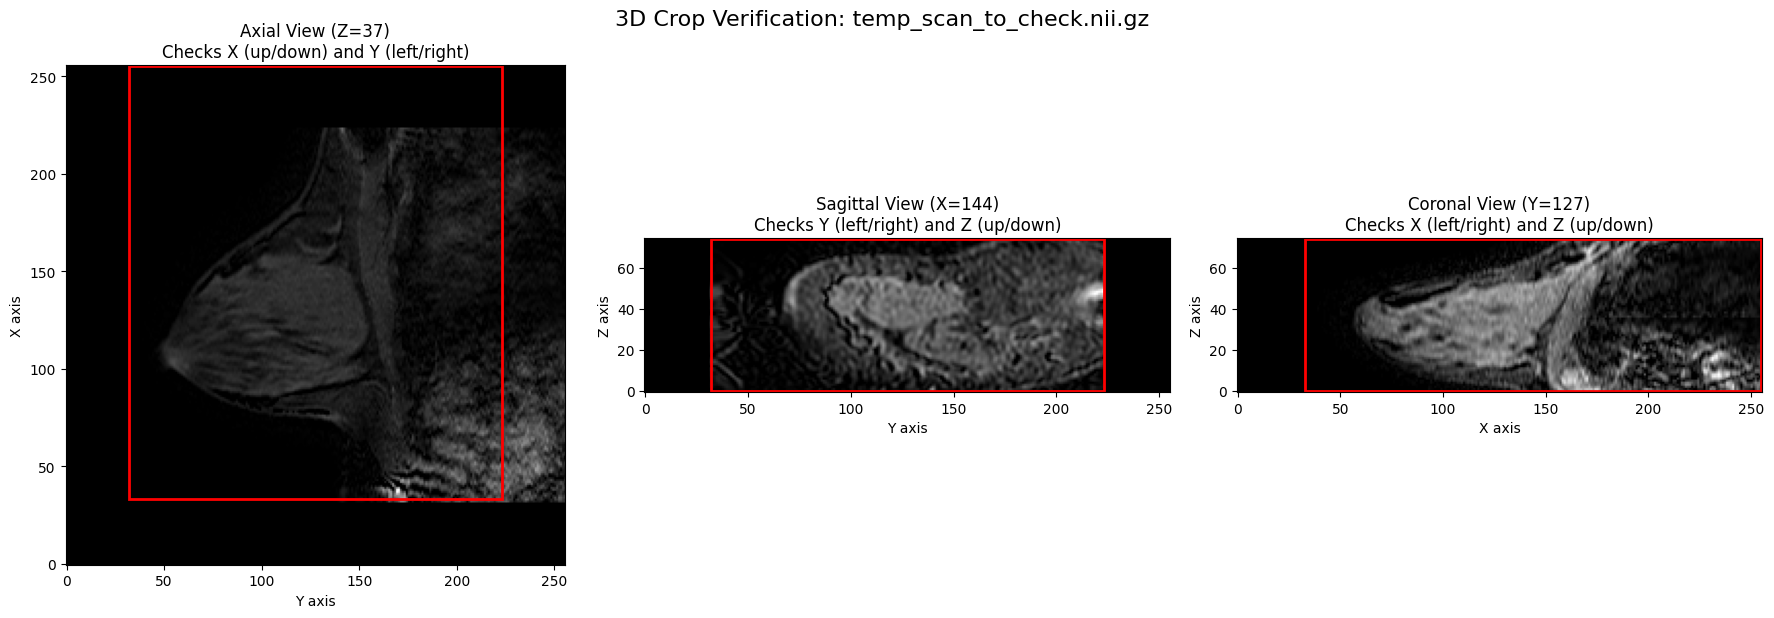

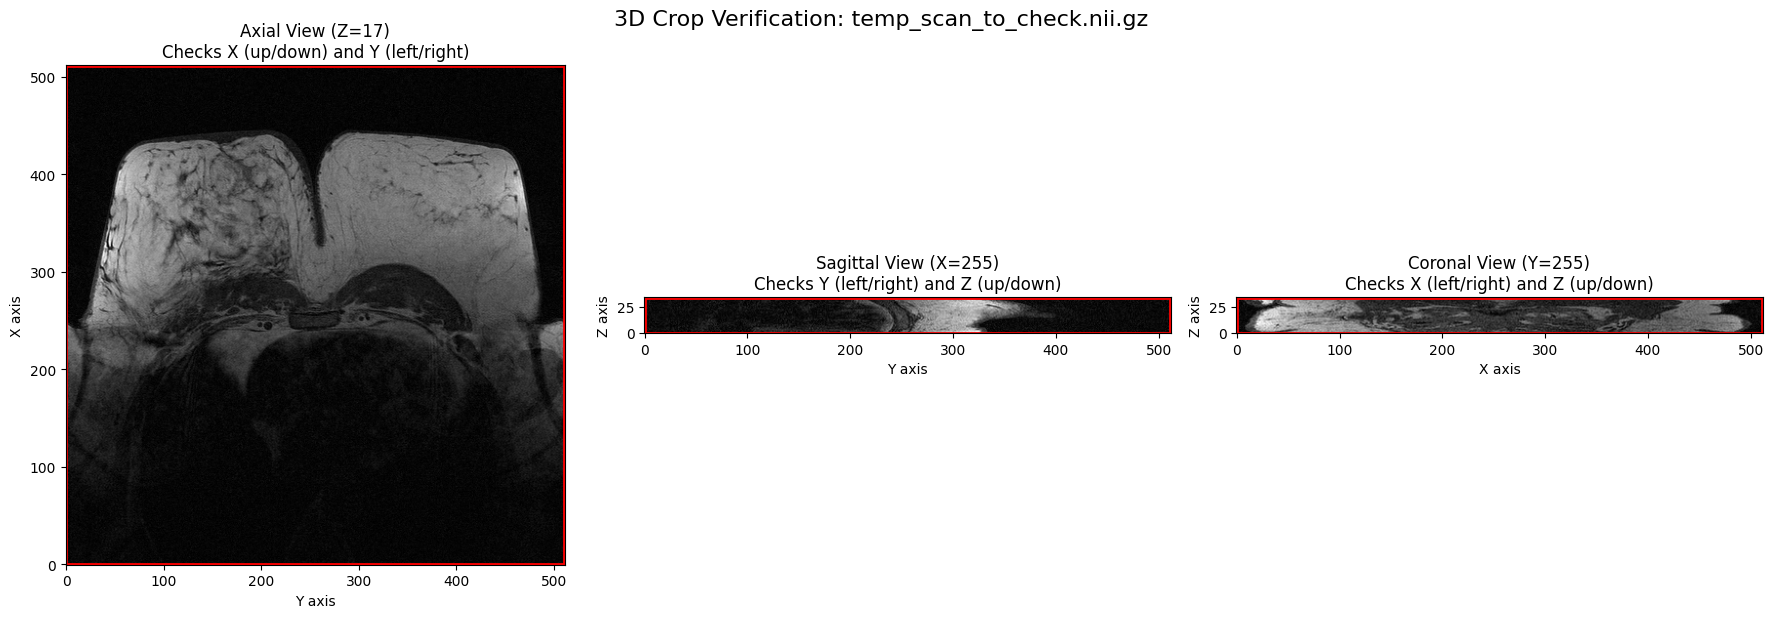

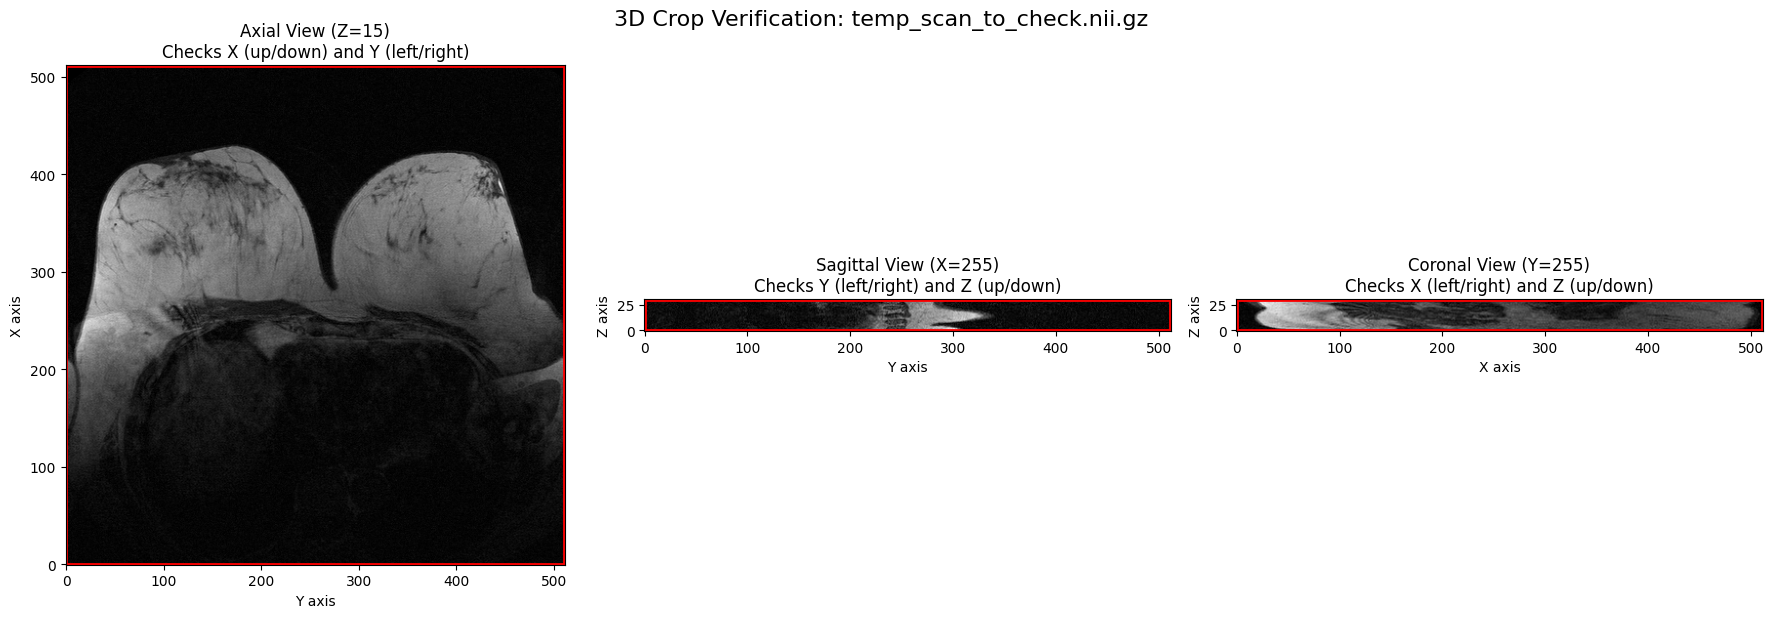

In [94]:
bucket_path_ica = "playground-dl/nifti_data"
temp_filename = "temp_scan_to_check.nii.gz" 

count = 0 
for file_path in fs.ls(bucket_path_ica):
    
    if file_path.endswith(".nii.gz"):
        
        try:
            fs.get(file_path, temp_filename)
        
            verify_crop_integrity(temp_filename)
            count += 1
        
            if count >= 3: 
                break
            
        except Exception as e:
            print(f"File Error {file_path} : {e}")


## Image Reduction: Otsu Method

Otsu method performs effectively reducing the original image size by 25% on average. However, size reduction is limited for certain images due to the dimensions of the original MRI.

In [ ]:
import gcsfs
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from scipy.ndimage import label, binary_opening, binary_closing
from scipy.signal import find_peaks, savgol_filter
import math

def voxel_patch(n_voxels, volume, bx, by ): 
    """ 
    Extracts a centered cubic subset from a 3D volume.
    The patch size is calculated to contain at least n_voxels.
    """
    
    size = math.ceil(math.cbrt(n_voxels) / 2 )  
    x, y, z = volume.shape

    z_center = z // 2 

    subset_volume = volume[bx - size : bx + size, 
                           by - size : by + size,
                           z_center - size : z_center + size ]

    return subset_volume 

def get_2d_center_of_mass_axial(image_input, split, peaks, treshold_pix=2000, treshold=0.5, kernel_size = 7, floor_percent = 0.20 ):
    """
    Calculates the center of mass only in areas where a peak has been detected
    """

    result = []
    debbug = []
    has_top_breast = any(p < split for p in peaks)
    has_bottom_breast = any(p >= split for p in peaks)
    
    image_list = []
    
    # Verify whether both breasts or a single breast are present
    if has_top_breast:
        image_top = image_input[:split, :].copy()
        image_list.append((image_top, 0))
    
    if has_bottom_breast:
        image_bottom = image_input[split:, :].copy()
        image_list.append((image_bottom, split))
    
    for image, offset in image_list:
        h, w = image.shape 
        y_sub1 = int(w * treshold) 
        image[:, :y_sub1] = 0
        
        # Removing noise artifacts from the image
        clean_image = np.where(image > treshold_pix, image, 0)
        binary_mask = (clean_image > 0).astype(int)
        
        # Stabilizing the signal through morphological cleaning
        kernel = np.ones((kernel_size,kernel_size))
        binary_mask = binary_opening(binary_mask, structure=kernel)
        binary_mask = binary_closing(binary_mask, structure=kernel)

        labeled_mask, num_features = label(binary_mask)
        
        if num_features == 0:
            continue
        
        sizes = ndimage.sum(binary_mask, labeled_mask, range(1, num_features + 1))
        largest_component = np.argmax(sizes) + 1
        
        # Extract the largest connected component

        final_mask = (labeled_mask == largest_component)
        clean_image_filtered = clean_image * final_mask

        if np.sum(clean_image_filtered) == 0:
            continue

        max_val = np.max(clean_image_filtered)
        floor_limit = max_val * floor_percent 
        clamped_image = np.where(clean_image_filtered > floor_limit, clean_image_filtered, 0)

        # Calculate the center of mass
        cy_local, cx_local = ndimage.center_of_mass(clamped_image)
        
        if np.isnan(cy_local) or np.isnan(cx_local):
            continue
        
        cy_global = cy_local + offset
        result.append((cx_local, cy_global))
        debbug.append(clamped_image)
    
    return result, debbug

def get_2d_center_of_mass_sagittal(image_input, treshold_pix=1500, treshold=0.5, kernel_size = 7,floor_percent = 0.2):
    """
    Calculates the center of mass for breast MRI sagittal views
    """

    image_2d = image_input.copy()
    h, w = image_2d.shape 
    
    # Removing noise artifacts from the image
    x_sub1 = int(h * treshold)
    image_2d[x_sub1:, :] = 0
    clean_image = np.where(image_2d > treshold_pix, image_2d, 0)
    
    # Stabilizing the signal through morphological cleaning
    kernel = np.ones((kernel_size,kernel_size))

    binary_mask = (clean_image > 0).astype(int)
    binary_mask = binary_closing(binary_mask, structure=kernel)
    binary_mask = binary_closing(binary_mask, structure=kernel)

    labeled_mask, num_features = label(binary_mask)
    
    # Handle cases where no components are found
    if num_features == 0:
        return w // 2, h // 2  
    
    # Extract the largest connected component
    sizes = ndimage.sum(binary_mask, labeled_mask, range(1, num_features + 1))
    largest_component_label = np.argmax(sizes) + 1
    
    final_mask = (labeled_mask == largest_component_label)
    
    # Calculate the center of mass
    clean_image_filtered = clean_image * final_mask
    max_val = np.max(clean_image_filtered)
    floor_limit = max_val * floor_percent 

    clamped_image = np.where(clean_image_filtered > floor_limit, clean_image_filtered, 0)
    cy, cx = ndimage.center_of_mass(clamped_image)
    
    if np.isnan(cx) or np.isnan(cy):
        return w // 2, h // 2

    return cx, cy, clamped_image

def get_split_corr(profile_smooth):

    width = len(profile_smooth)
    center_img = width // 2
    
    # Configuration parameters
    center_tolerance_percent = 0.15
    limit_left = int(width * (0.5 - center_tolerance_percent/2))
    limit_right = int(width * (0.5 + center_tolerance_percent/2))
    
    # Use signal intensity to filter out small non-breast peaks
    max_search_dist = int(width * 0.4)
    signal_range = np.max(profile_smooth) - np.min(profile_smooth)

    prominence = signal_range * 0.25
    peaks, _ = find_peaks(profile_smooth, distance=width//5, prominence=prominence)
    
    if len(peaks) == 0:
        return center_img, []

    # Categorize peaks by position: left, right, or center
    peaks_in_left = [p for p in peaks if p < limit_left]
    peaks_in_right = [p for p in peaks if p > limit_right]
    peaks_in_center = [p for p in peaks if limit_left <= p <= limit_right]
    
    split_idx = center_img
    used_peaks = []

    # Case 1: Bilateral detection both breasts
    if len(peaks_in_left) > 0 and len(peaks_in_right) > 0:
        
        best_left = peaks_in_left[np.argmax(profile_smooth[peaks_in_left])]
        best_right = peaks_in_right[np.argmax(profile_smooth[peaks_in_right])]
        
        valley = profile_smooth[best_left:best_right]
        min_rel = np.argmin(valley)
        split_idx = best_left + min_rel
        
        used_peaks = [best_left, best_right]

    # Case 2: Left breast only
    elif len(peaks_in_left) > 0 and len(peaks_in_right) == 0:
        ref_peak = np.max(peaks_in_left)
        
        search_end = min(width, ref_peak + max_search_dist)
        search_zone = profile_smooth[ref_peak:search_end]
        
        split_idx = ref_peak + np.argmin(search_zone)
        used_peaks = [ref_peak]

    # Case 3: Right breast only
    elif len(peaks_in_right) > 0 and len(peaks_in_left) == 0:
        ref_peak = np.min(peaks_in_right)
        
        search_start = max(0, ref_peak - max_search_dist)
        search_zone = profile_smooth[search_start:ref_peak]
        
        split_idx = search_start + np.argmin(search_zone)
        used_peaks = [ref_peak]

    # Case 4: Peak in the center single breast
    else:
        split_idx = center_img
        used_peaks = peaks_in_center

    return split_idx, used_peaks

In [25]:
import json

with open('orientation.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

data_sagittal = [key for key, val in data.items() if  val =="Sagittal" ]
data_axial    = [key for key, val in data.items() if  val =="Axial" ]

DCE_0001.nii.gz
Split Idx : 250
Peaks X : [np.int64(77), np.int64(431)]


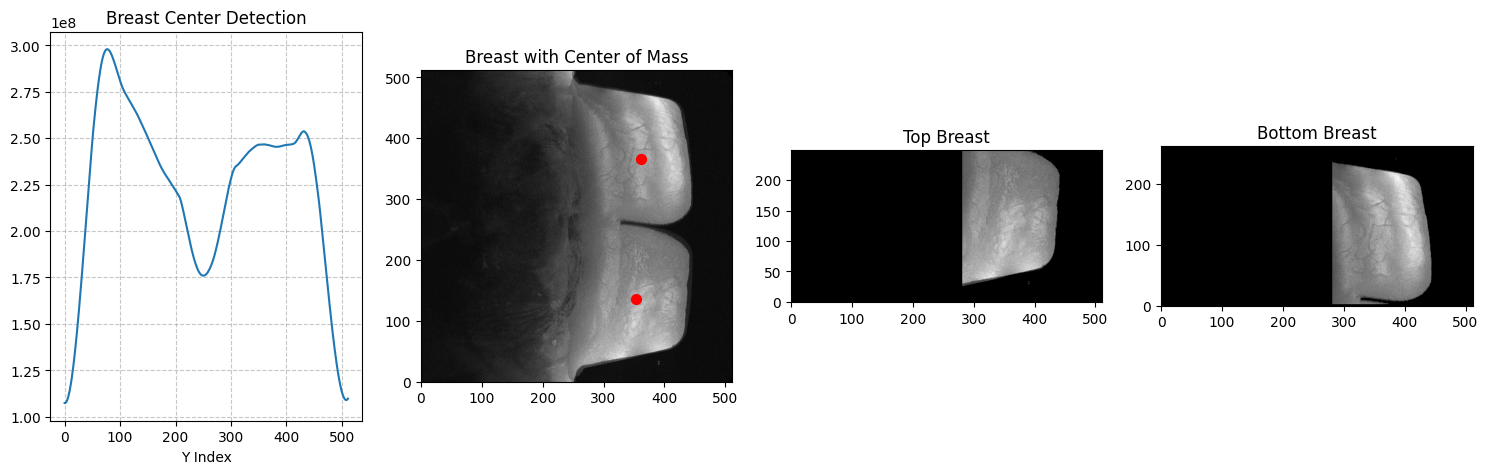

DCE_0008.nii.gz
Split Idx : 250
Peaks X : [np.int64(105)]


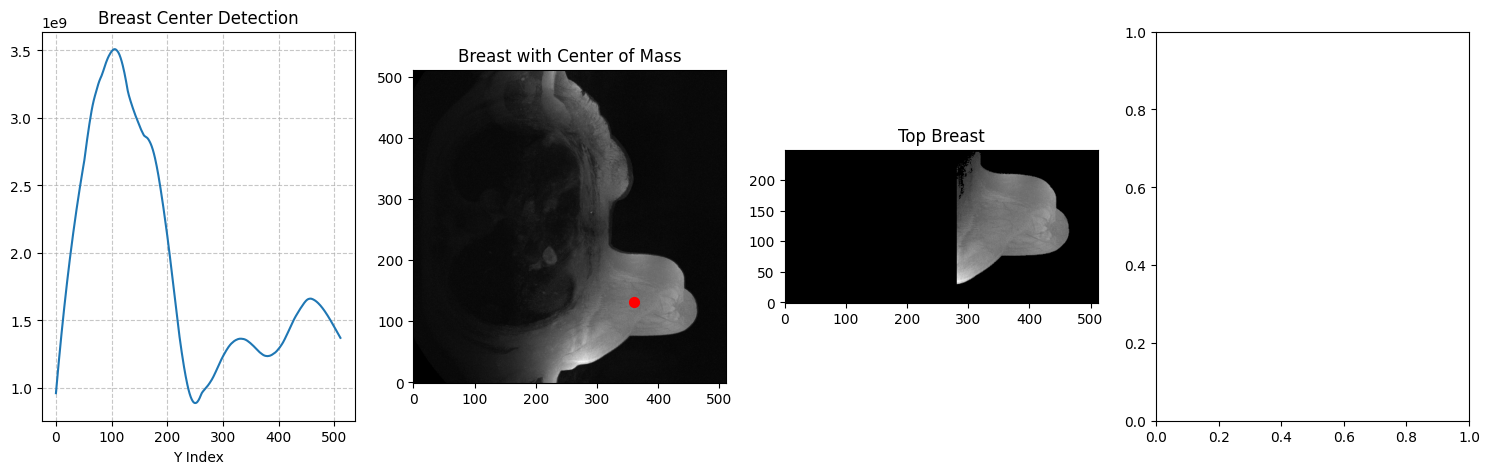

DCE_0022.nii.gz
Split Idx : 256
Peaks X : [np.int64(104), np.int64(414)]


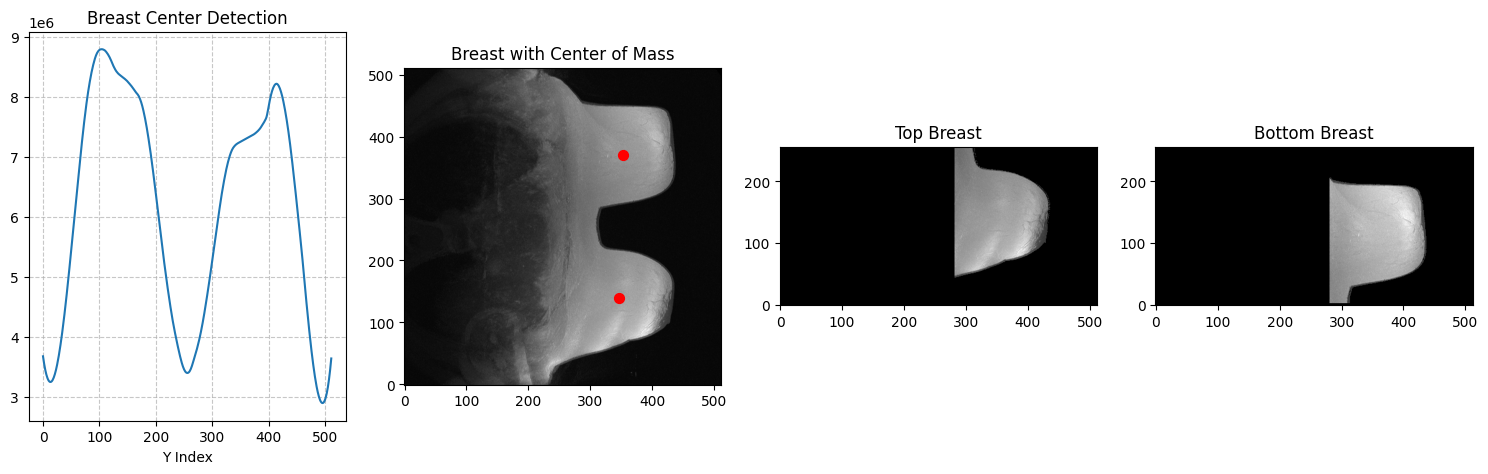

DCE_0012.nii.gz
Split Idx : 274
Peaks X : [np.int64(145), np.int64(343)]


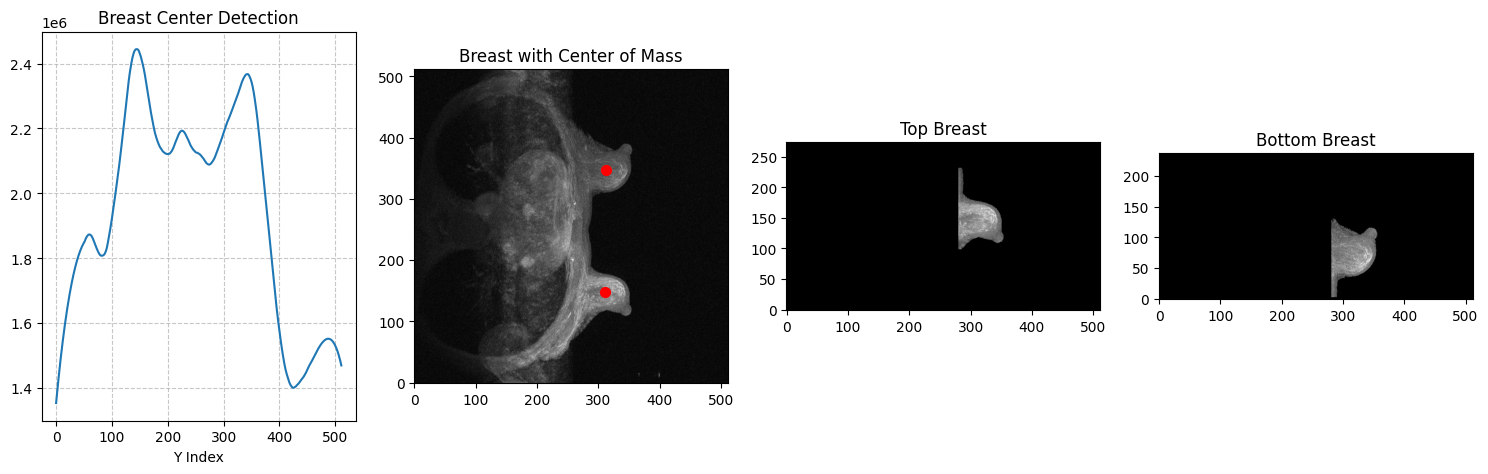

DCE_0019.nii.gz
Split Idx : 268
Peaks X : [np.int64(147), np.int64(349)]


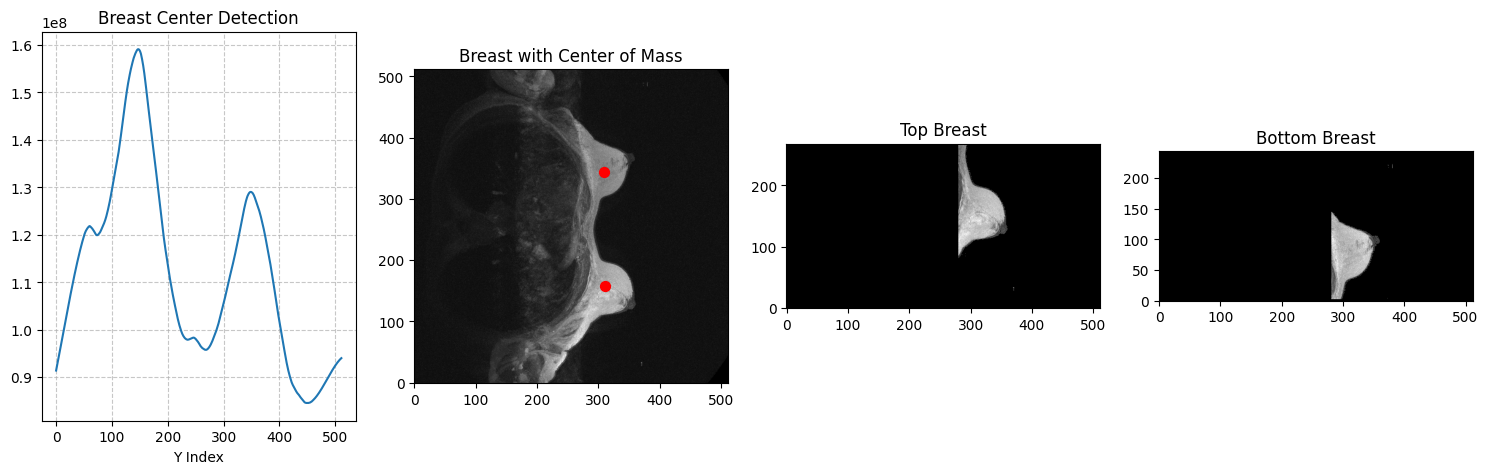

In [ ]:
fs = gcsfs.GCSFileSystem() 
bucket_path_ica = "playground-dl/nifti_data/"
temp_filename = "temp_scan_to_check.nii.gz"
count = 0 

data_axial = ["DCE_0001.nii.gz", "DCE_0008.nii.gz", "DCE_0022.nii.gz", "DCE_0012.nii.gz", "DCE_0019.nii.gz"]

for file_name in data_axial:
    try:
        file_path = bucket_path_ica + file_name
        
        fs.get(file_path, temp_filename)
        img = nib.load(temp_filename)
        vol = img.get_fdata()
        if vol.ndim == 4:
            vol_3d = vol[..., 0]
        else:
            vol_3d = vol

        print(file_name)
        twod_image = np.max(vol_3d, axis=2)
        one_image = np.sum(twod_image, axis=1) 

        width = len(one_image)
        window = width // 5 

        if window % 2 == 0:
            window += 1 

        profile_lisse = savgol_filter(one_image, window_length=window, polyorder=3)
        split, peaks = get_split_corr(profile_lisse)
        result, debbug = get_2d_center_of_mass_axial(twod_image, split, peaks , treshold = 0.55)
        print(f"Split Idx : {split}")
        print(f"Peaks X : {peaks}")

        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5))

        ax1.plot(profile_lisse)
        ax1.set_title("Breast Center Detection")
        ax1.grid(True, linestyle='--', alpha=0.7) 
        ax1.set_xlabel("Y Index")           
        
        ax2.imshow(twod_image, cmap='gray', origin='lower') 
        
        for (cx, cy) in result:
            ax2.scatter(cx, cy, c='red', s=50, marker='o', label='Breast Center')
        ax2.set_title("Breast with Center of Mass")

        ax3.imshow(debbug[0], cmap='gray', origin='lower') 
        ax3.set_title("Top Breast")

        if len(debbug) > 1:
            ax4.imshow(debbug[1], cmap='gray', origin='lower') 
            ax4.set_title("Bottom Breast")

        plt.tight_layout()
        plt.show()

            
    except Exception as e:
        print(f"Error on {file_path} : {e}")

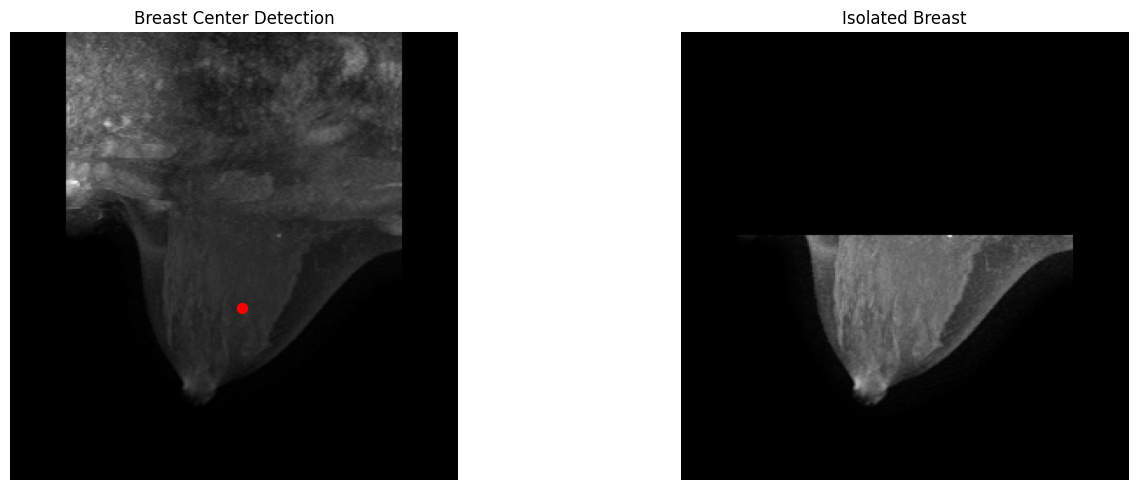

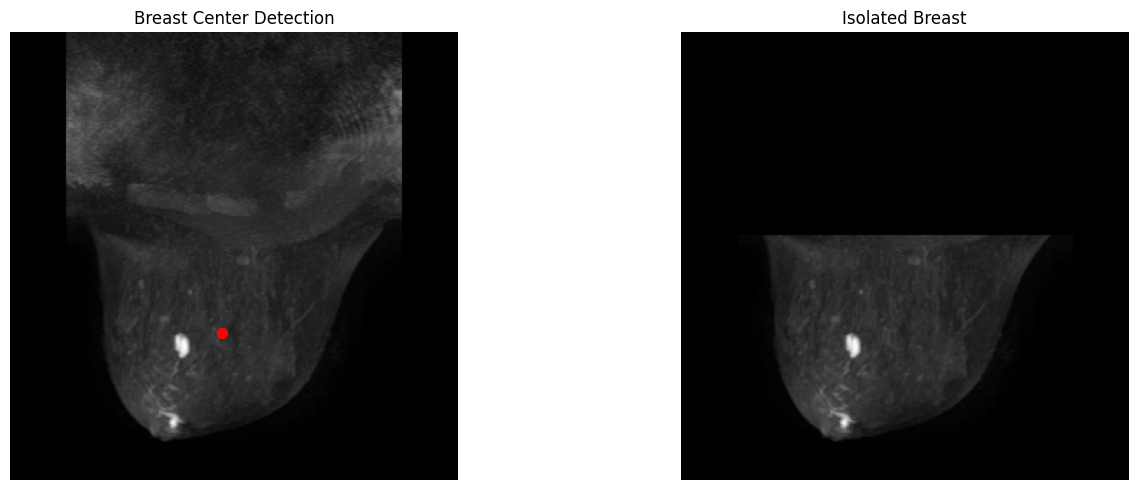

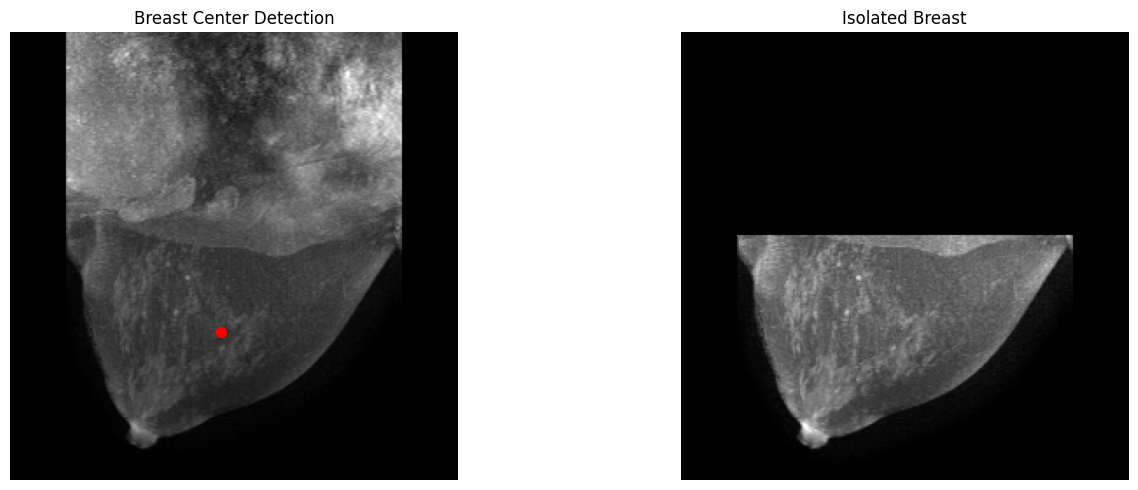

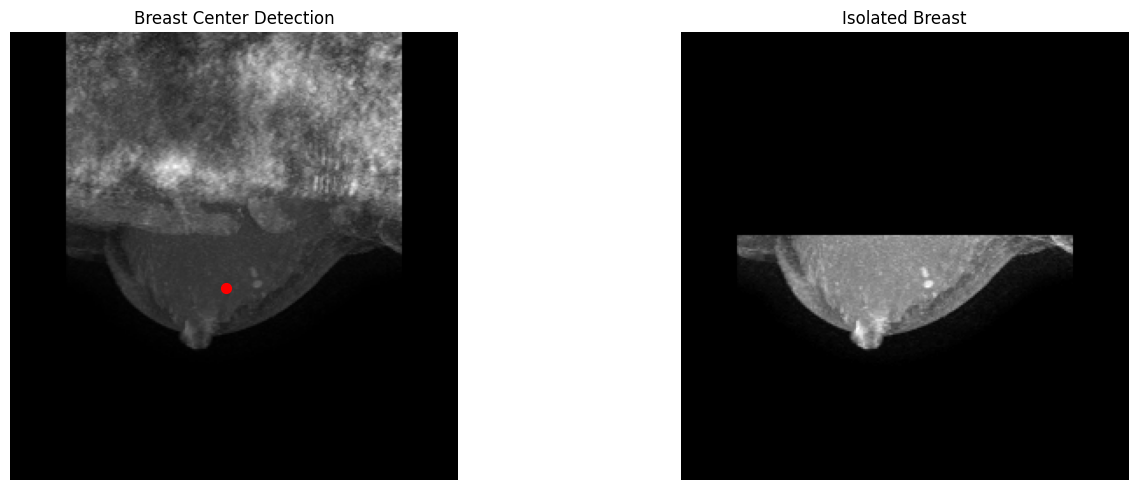

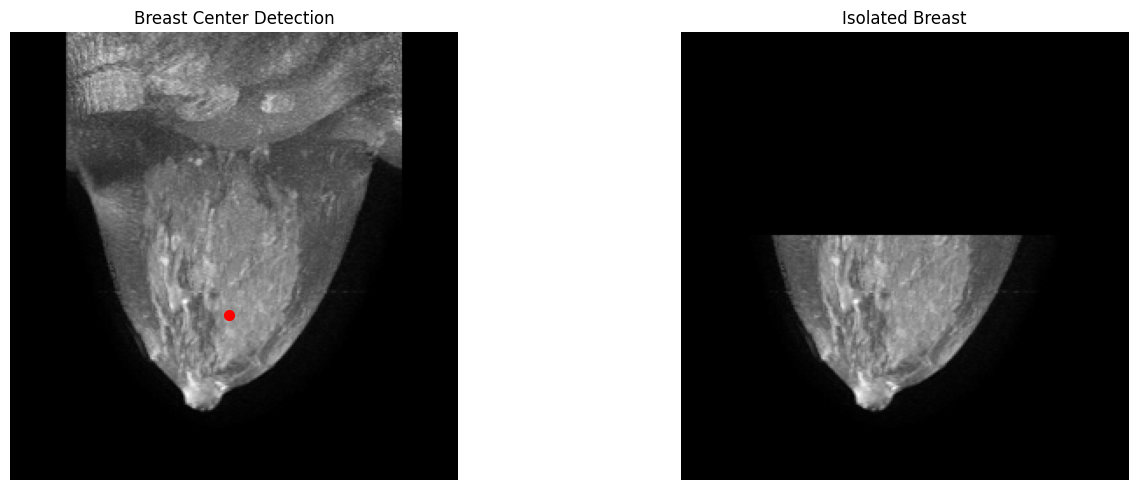

In [80]:
count = 0 

for file_name in data_sagittal:
        try:
            file_path = bucket_path_ica + file_name
            fs.get(file_path, temp_filename)
            img = nib.load(temp_filename)
            vol = img.get_fdata()

            if vol.ndim == 4:
                vol_3d = vol[..., 0]
            else:
                vol_3d = vol
            twod_image = np.max(vol_3d, axis=2)
            cx2,cy2, isolated_object = get_2d_center_of_mass_sagittal(twod_image, treshold=0.55)

            test = twod_image.copy()
            x, y = test.shape 

            test_sub = int(x*0.6)
            test[test_sub:,: ] = 0
            fig, (ax1 , ax2)  = plt.subplots(1, 2, figsize=(15, 5))

            ax1.imshow(twod_image, cmap='gray', origin='lower')
            ax1.scatter(cx2, cy2, c='red', s=50, marker='o', label='Centre Sein')
            ax1.set_title("Breast Center Detection")
            ax1.axis('off')

            ax2.imshow(isolated_object, cmap='gray', origin='lower')
            ax2.set_title("Isolated Breast")
            ax2.axis('off')

            plt.tight_layout()
            plt.show()

            count += 1
            if count >= 5: 
                break
                
        except Exception as e:
            print(f"Error on {file_path} : {e}")


## Registration: Anchoring

The optimal anchor point for image registration is located within the breast. To achieve this, I employ two different algorithms based on the center of mass of the largest connected component. This approach mitigates noise and stabilizes the results. Additionally, we detect the number of breasts and the split point between them. This will significantly improves registration effectiveness on axial MRI scans, as it allows for focused processing of a single breast rather than both simultaneously